# Q and A on flights dataset using ChatGPT


## 1. Trend Questions
```
Is the passenger trend going up or down over the years? 
What was the total number of passengers for each year?
Which year had the highest number of passengers?
```

## 2. Seasonality Questions
```
Which month is the busiest month of the year?
Which month has the lowest number of passengers?
Are summer months busier than winter months? 
```

## 3. Forecasting Questions
```
What is the average monthly growth rate of passengers?
Predict the passenger count for next month using a simple average
```

## 4. Query
```
What was the passenger count in July 1960 compared to July 1950?
```

# Get the dataset

In [1]:
import seaborn as sns

# Load the dataset
flights = sns.load_dataset("flights")

# Save to CSV without index
flights.to_csv("data_flights.csv", index=False)


# Load the dataset to chatGPT

# Prompt:
Is the passenger trend going up or down over the years? Give me the code so I can run on my computer

Correlation between year and total passengers: 0.993
Passenger trend is going UP over the years.


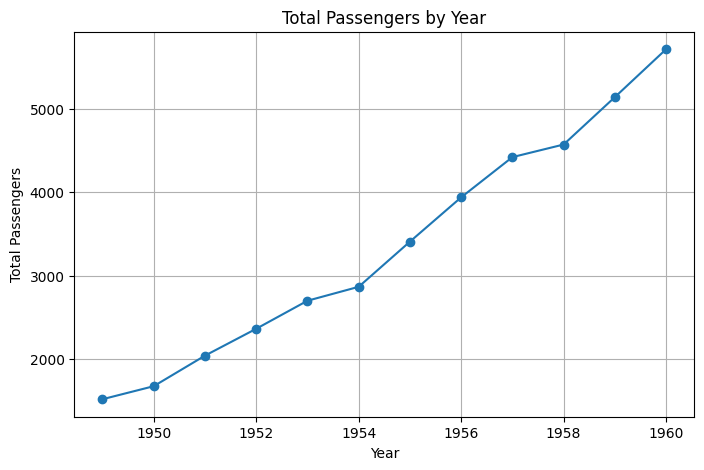

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("data_flights.csv")

# Aggregate total passengers by year
yearly_passengers = df.groupby("year")["passengers"].sum()

# Check overall trend using correlation
correlation = yearly_passengers.index.to_series().corr(yearly_passengers)
print(f"Correlation between year and total passengers: {correlation:.3f}")

if correlation > 0:
    print("Passenger trend is going UP over the years.")
elif correlation < 0:
    print("Passenger trend is going DOWN over the years.")
else:
    print("Passenger trend is FLAT over the years.")

# Plot the trend
plt.figure(figsize=(8, 5))
plt.plot(yearly_passengers.index, yearly_passengers.values, marker="o")
plt.title("Total Passengers by Year")
plt.xlabel("Year")
plt.ylabel("Total Passengers")
plt.grid(True)
plt.show()

# Prompt: 
What was the total number of passengers for each year?  Give me the code

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv("data_flights.csv")

# Calculate total passengers for each year
yearly_totals = df.groupby("year")["passengers"].sum().reset_index()

# Rename the column for clarity
yearly_totals.columns = ["year", "total_passengers"]

# Print the results
print(yearly_totals)

# Optional: save to a CSV file
# yearly_totals.to_csv("yearly_passenger_totals.csv", index=False)

    year  total_passengers
0   1949              1520
1   1950              1676
2   1951              2042
3   1952              2364
4   1953              2700
5   1954              2867
6   1955              3408
7   1956              3939
8   1957              4421
9   1958              4572
10  1959              5140
11  1960              5714


# Prompt:
Which year had the highest number of passengers? I want the visual too. Give me the code

Year with the highest number of passengers: 1960
Total passengers: 5,714

Total passengers by year:
    year  total_passengers
0   1949              1520
1   1950              1676
2   1951              2042
3   1952              2364
4   1953              2700
5   1954              2867
6   1955              3408
7   1956              3939
8   1957              4421
9   1958              4572
10  1959              5140
11  1960              5714


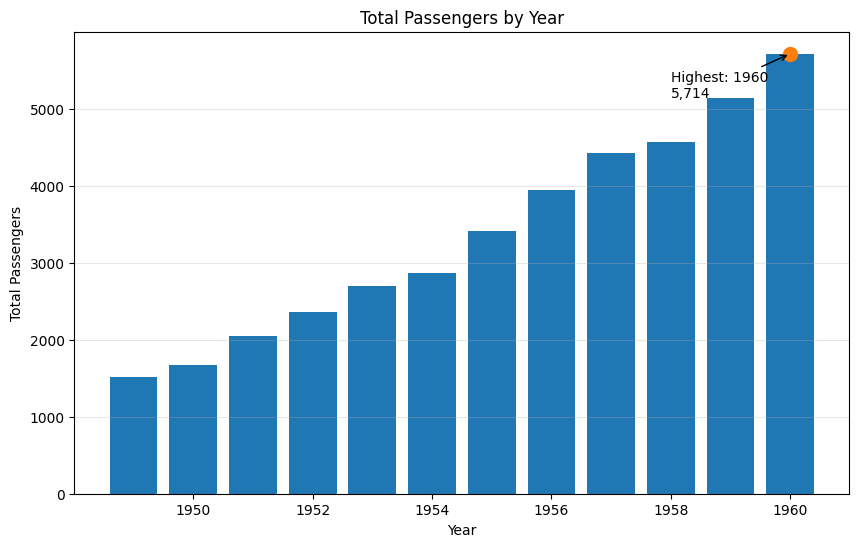

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("data_flights.csv")

# Calculate total passengers for each year
yearly_totals = df.groupby("year")["passengers"].sum().reset_index()
yearly_totals.columns = ["year", "total_passengers"]

# Find the year with the highest number of passengers
max_row = yearly_totals.loc[yearly_totals["total_passengers"].idxmax()]
max_year = max_row["year"]
max_passengers = max_row["total_passengers"]

# Print the result
print(f"Year with the highest number of passengers: {max_year}")
print(f"Total passengers: {max_passengers:,}")

# Print all yearly totals
print("\nTotal passengers by year:")
print(yearly_totals)

# Create the visualization
plt.figure(figsize=(10, 6))
plt.bar(yearly_totals["year"], yearly_totals["total_passengers"])

# Highlight the highest year with a marker and annotation
plt.scatter(max_year, max_passengers, s=100, zorder=3)
plt.annotate(
    f"Highest: {int(max_year)}\n{int(max_passengers):,}",
    xy=(max_year, max_passengers),
    xytext=(max_year - 2, max_passengers * 0.9),
    arrowprops=dict(arrowstyle="->")
)

# Labels and title
plt.title("Total Passengers by Year")
plt.xlabel("Year")
plt.ylabel("Total Passengers")
plt.grid(axis="y", alpha=0.3)

# Show the chart
plt.show()

# Prompt: 
Which month is the busiest month of the year? Give me the code. I also would like to visualize\

Busiest month: Jul
Total passengers across all years: 4,216


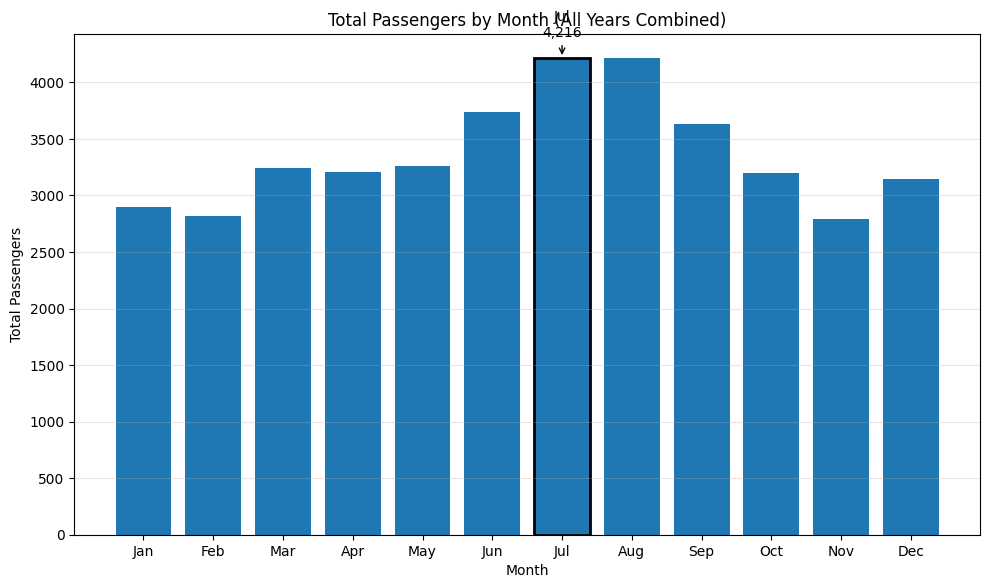

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("data_flights.csv")

# Calculate total passengers for each month across all years
monthly_totals = df.groupby("month")["passengers"].sum().reset_index()
monthly_totals.columns = ["month", "total_passengers"]

# If the month column contains names like 'Jan', 'Feb', etc.,
# define the correct order for sorting
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Convert to ordered categorical if month is text
if monthly_totals["month"].dtype == "object":
    monthly_totals["month"] = pd.Categorical(
        monthly_totals["month"],
        categories=month_order,
        ordered=True
    )
    monthly_totals = monthly_totals.sort_values("month")

# Find the busiest month
max_row = monthly_totals.loc[monthly_totals["total_passengers"].idxmax()]
busiest_month = str(max_row["month"])
max_passengers = max_row["total_passengers"]

# Print the result
print(f"Busiest month: {busiest_month}")
print(f"Total passengers across all years: {max_passengers:,}")

# Create the visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(
    monthly_totals["month"].astype(str),
    monthly_totals["total_passengers"]
)

# Highlight the busiest month
max_index = monthly_totals["total_passengers"].idxmax()
bars[list(monthly_totals.index).index(max_index)].set_edgecolor("black")
bars[list(monthly_totals.index).index(max_index)].set_linewidth(2)

# Add annotation
plt.annotate(
    f"{busiest_month}\n{int(max_passengers):,}",
    xy=(list(monthly_totals.index).index(max_index), max_passengers),
    xytext=(0, 15),
    textcoords="offset points",
    ha="center",
    arrowprops=dict(arrowstyle="->")
)

# Labels and title
plt.title("Total Passengers by Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Total Passengers")
plt.grid(axis="y", alpha=0.3)

# Show the chart
plt.tight_layout()
plt.show()

# Prompt:
Which month has the lowest number of passengers? I want the code that shows visual

Month with the lowest number of passengers: Nov
Total passengers across all years: 2,794


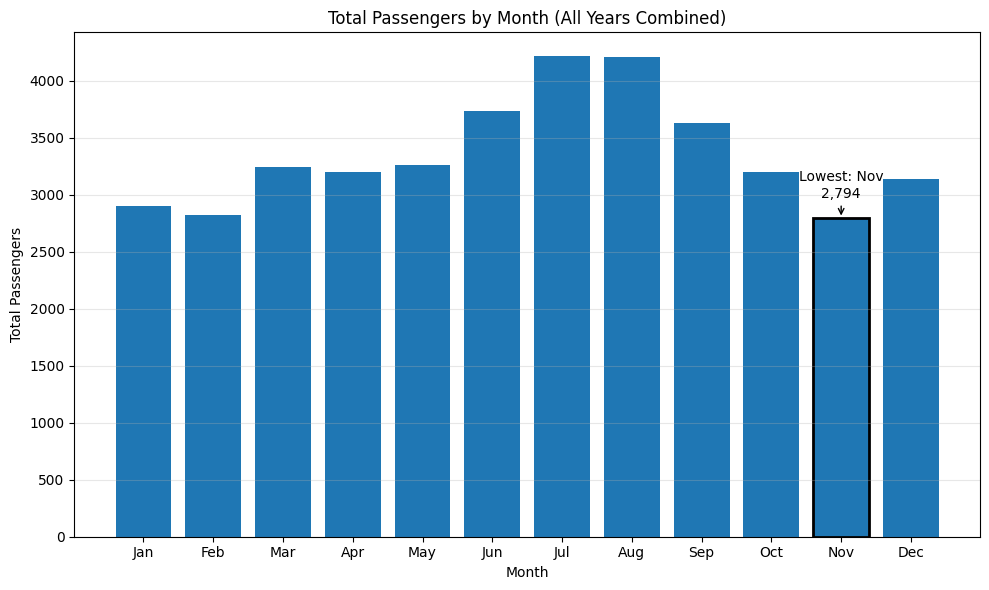

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("data_flights.csv")

# Calculate total passengers for each month across all years
monthly_totals = df.groupby("month")["passengers"].sum().reset_index()
monthly_totals.columns = ["month", "total_passengers"]

# Define month order (for datasets where month is stored as text like 'Jan', 'Feb', etc.)
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Sort months correctly if the month column contains text
if monthly_totals["month"].dtype == "object":
    monthly_totals["month"] = pd.Categorical(
        monthly_totals["month"],
        categories=month_order,
        ordered=True
    )
    monthly_totals = monthly_totals.sort_values("month")

# Find the month with the lowest number of passengers
min_row = monthly_totals.loc[monthly_totals["total_passengers"].idxmin()]
lowest_month = str(min_row["month"])
min_passengers = min_row["total_passengers"]

# Print the result
print(f"Month with the lowest number of passengers: {lowest_month}")
print(f"Total passengers across all years: {min_passengers:,}")

# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(
    monthly_totals["month"].astype(str),
    monthly_totals["total_passengers"]
)

# Highlight the lowest month
min_index = monthly_totals["total_passengers"].idxmin()
bar_position = list(monthly_totals.index).index(min_index)
bars[bar_position].set_edgecolor("black")
bars[bar_position].set_linewidth(2)

# Add annotation
plt.annotate(
    f"Lowest: {lowest_month}\n{int(min_passengers):,}",
    xy=(bar_position, min_passengers),
    xytext=(0, 15),
    textcoords="offset points",
    ha="center",
    arrowprops=dict(arrowstyle="->")
)

# Labels and title
plt.title("Total Passengers by Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Total Passengers")
plt.grid(axis="y", alpha=0.3)

# Show the chart
plt.tight_layout()
plt.show()

# Prompt:
Are summer months busier than winter months? Give me the viosual and the code

   season  passengers
0  Summer       12169
1  Winter        8863

Summer months are busier than winter months.


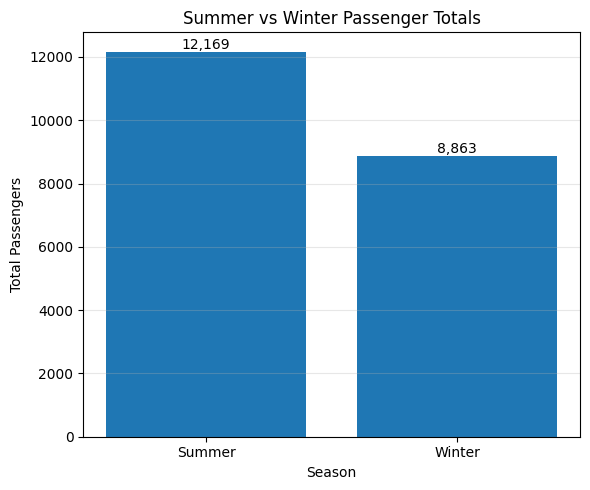

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("data_flights.csv")

# If month is stored as names (e.g., Jan, Feb, ...)
# map them to month numbers
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

if df["month"].dtype == "object":
    df["month_num"] = df["month"].map(month_map)
else:
    df["month_num"] = df["month"]

# Define seasons
# Summer = June, July, August
# Winter = December, January, February
df["season"] = df["month_num"].apply(
    lambda m: "Summer" if m in [6, 7, 8]
    else ("Winter" if m in [12, 1, 2] else "Other")
)

# Keep only Summer and Winter
season_df = df[df["season"].isin(["Summer", "Winter"])]

# Total passengers by season
season_totals = (
    season_df.groupby("season")["passengers"]
    .sum()
    .reindex(["Summer", "Winter"])
    .reset_index()
)

# Print totals
print(season_totals)

# Determine which season is busier
summer_total = season_totals.loc[
    season_totals["season"] == "Summer", "passengers"
].values[0]

winter_total = season_totals.loc[
    season_totals["season"] == "Winter", "passengers"
].values[0]

if summer_total > winter_total:
    print("\nSummer months are busier than winter months.")
elif winter_total > summer_total:
    print("\nWinter months are busier than summer months.")
else:
    print("\nSummer and winter have the same total number of passengers.")

# Visualization
plt.figure(figsize=(6, 5))
bars = plt.bar(
    season_totals["season"],
    season_totals["passengers"]
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

# Labels and title
plt.title("Summer vs Winter Passenger Totals")
plt.xlabel("Season")
plt.ylabel("Total Passengers")
plt.grid(axis="y", alpha=0.3)

# Show the chart
plt.tight_layout()
plt.show()

# promtpt: 
What is the average monthly growth rate of passengers?


Average monthly growth rate: 1.52%

First 10 monthly growth rates:
    year month  passengers  growth_rate_pct
1   1949   Feb         118         5.357143
2   1949   Mar         132        11.864407
3   1949   Apr         129        -2.272727
4   1949   May         121        -6.201550
5   1949   Jun         135        11.570248
6   1949   Jul         148         9.629630
7   1949   Aug         148         0.000000
8   1949   Sep         136        -8.108108
9   1949   Oct         119       -12.500000
10  1949   Nov         104       -12.605042


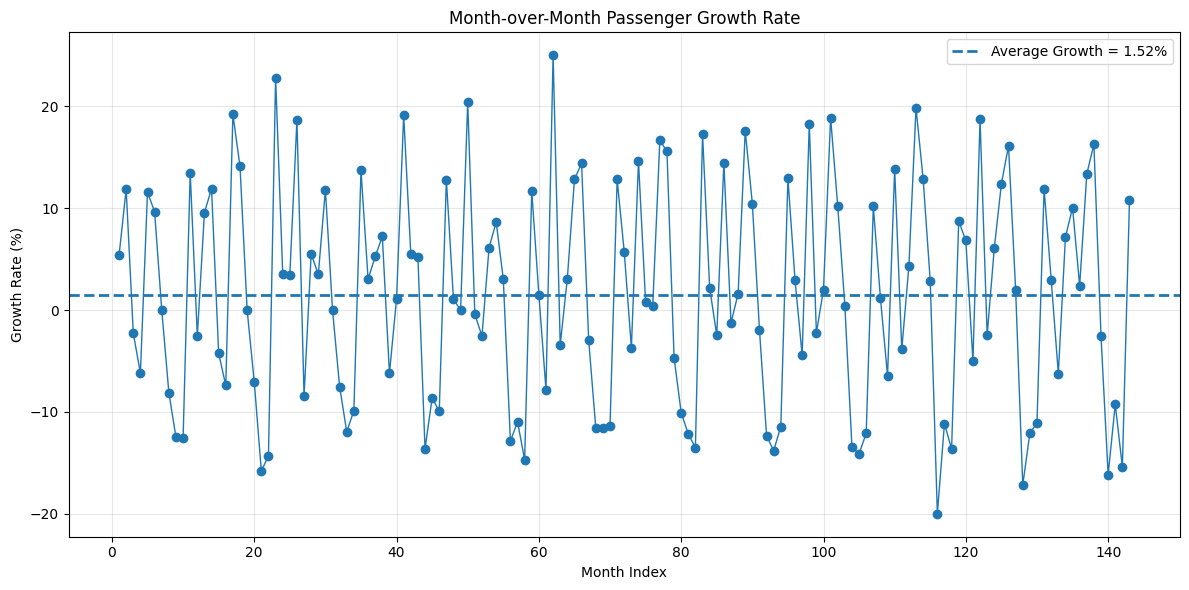

In [15]:

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("data_flights.csv")

# If month is stored as text (e.g., Jan, Feb, ...)
# convert it to month numbers so we can sort correctly
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

if df["month"].dtype == "object":
    df["month_num"] = df["month"].map(month_map)
else:
    df["month_num"] = df["month"]

# Sort by year and month
df = df.sort_values(["year", "month_num"]).reset_index(drop=True)

# Calculate month-over-month growth rate (%)
df["growth_rate_pct"] = df["passengers"].pct_change() * 100

# Remove the first row (it has NaN because there is no previous month)
growth_df = df.dropna(subset=["growth_rate_pct"])

# Calculate average monthly growth rate
avg_growth = growth_df["growth_rate_pct"].mean()

# Print the result
print(f"Average monthly growth rate: {avg_growth:.2f}%")

# Optional: show the first few growth values
print("\nFirst 10 monthly growth rates:")
print(growth_df[["year", "month", "passengers", "growth_rate_pct"]].head(10))

# Visualization: growth rate over time
plt.figure(figsize=(12, 6))
plt.plot(growth_df["growth_rate_pct"], marker="o", linewidth=1)

# Add average growth line
plt.axhline(avg_growth, linestyle="--", linewidth=2,
            label=f"Average Growth = {avg_growth:.2f}%")

# Labels and title
plt.title("Month-over-Month Passenger Growth Rate")
plt.xlabel("Month Index")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)

# Show the chart
plt.tight_layout()
plt.show()


# Prompt:
Predict the passenger count for next month using a simple average. Give me the code and the visual

Predicted passengers for Jan 1961: 280


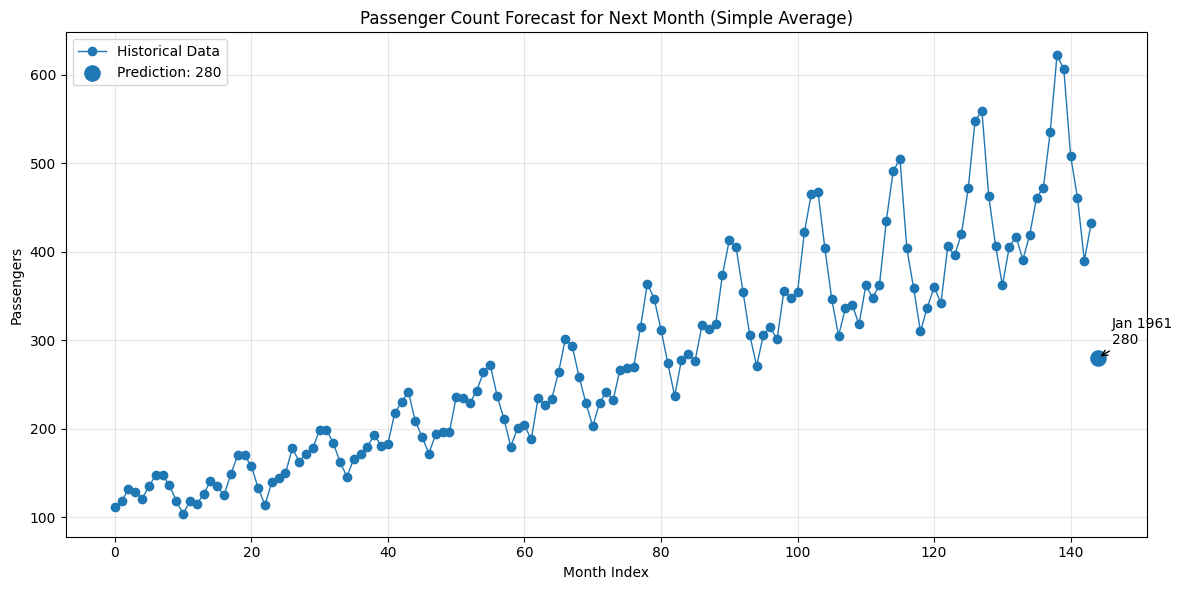

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("data_flights.csv")

# Convert month names to month numbers if needed
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

if df["month"].dtype == "object":
    df["month_num"] = df["month"].map(month_map)
else:
    df["month_num"] = df["month"]

# Sort data chronologically
df = df.sort_values(["year", "month_num"]).reset_index(drop=True)

# Simple average forecast:
# Predict next month's passengers as the average of all historical values
predicted_passengers = df["passengers"].mean()

# Identify the next month/year
last_year = df.iloc[-1]["year"]
last_month = df.iloc[-1]["month_num"]

if last_month == 12:
    next_month = 1
    next_year = last_year + 1
else:
    next_month = last_month + 1
    next_year = last_year

# Convert month number to month name
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

next_month_name = month_names[next_month]

# Print prediction
print(f"Predicted passengers for {next_month_name} {int(next_year)}: "
      f"{predicted_passengers:.0f}")

# Visualization
plt.figure(figsize=(12, 6))

# Plot historical passenger counts
plt.plot(df["passengers"].values, marker="o", linewidth=1, label="Historical Data")

# Plot predicted next month
plt.scatter(
    len(df),
    predicted_passengers,
    s=120,
    zorder=3,
    label=f"Prediction: {predicted_passengers:.0f}"
)

# Annotate prediction
plt.annotate(
    f"{next_month_name} {int(next_year)}\n{predicted_passengers:.0f}",
    xy=(len(df), predicted_passengers),
    xytext=(10, 10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Labels and title
plt.title("Passenger Count Forecast for Next Month (Simple Average)")
plt.xlabel("Month Index")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True, alpha=0.3)

# Show plot
plt.tight_layout()
plt.show()

# Prompt:
What was the passenger count in July 1960 compared to July 1950? - DONE


Passengers in July 1950: 170
Passengers in July 1960: 622
Difference: 452
Percent increase: 265.88%


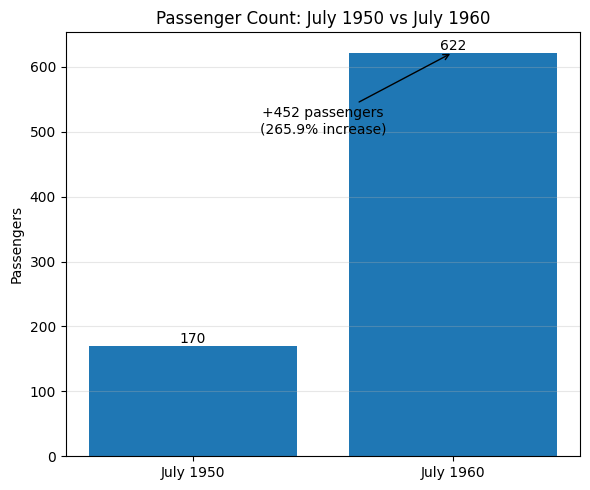

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("data_flights.csv")

# Filter for July 1950 and July 1960
july_1950 = df[(df["year"] == 1950) & (df["month"] == "Jul")]["passengers"].values[0]
july_1960 = df[(df["year"] == 1960) & (df["month"] == "Jul")]["passengers"].values[0]

# Calculate difference and percent increase
difference = july_1960 - july_1950
percent_increase = (difference / july_1950) * 100

# Print results
print(f"Passengers in July 1950: {july_1950}")
print(f"Passengers in July 1960: {july_1960}")
print(f"Difference: {difference}")
print(f"Percent increase: {percent_increase:.2f}%")

# Create comparison DataFrame
comparison = pd.DataFrame({
    "Period": ["July 1950", "July 1960"],
    "Passengers": [july_1950, july_1960]
})

# Visualization
plt.figure(figsize=(6, 5))
bars = plt.bar(comparison["Period"], comparison["Passengers"])

# Add labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

# Add annotation for increase
plt.annotate(
    f"+{difference} passengers\n({percent_increase:.1f}% increase)",
    xy=(1, july_1960),
    xytext=(0.5, july_1960 * 0.8),
    arrowprops=dict(arrowstyle="->"),
    ha="center"
)

# Labels and title
plt.title("Passenger Count: July 1950 vs July 1960")
plt.ylabel("Passengers")
plt.grid(axis="y", alpha=0.3)

# Show plot
plt.tight_layout()
plt.show()